In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('monthly_milk_production.csv')

In [3]:
df.shape

(168, 2)

In [4]:
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [6]:
df.describe()

,Production
count,168.000000
mean,754.708333
std,102.204524
min,553.000000
25%,677.750000
50%,761.000000
75%,824.500000
max,969.000000


In [7]:
### missing values
df.isnull().sum()

Date          0
Production    0
dtype: int64

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df.set_index('Date', inplace=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


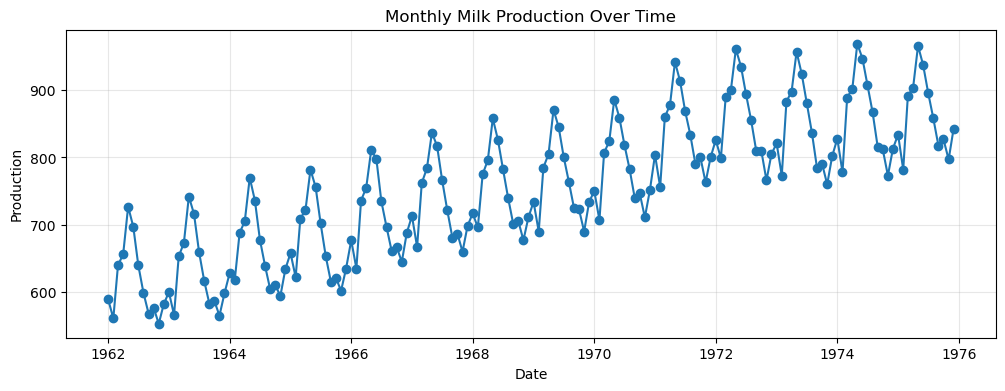

In [9]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Production'], marker='o', linestyle='-')
plt.title('Monthly Milk Production Over Time')
plt.xlabel('Date')
plt.ylabel('Production')
plt.grid(alpha=0.3)
plt.show()

In [10]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
df_scaled = scaler.fit_transform(df[['Production']])

In [11]:
# Function to create sequences
def create_sequences(data, window_size):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    X = np.array(X)
    y = np.array(y)
    return X, y

In [12]:
window_size = 12
X, y = create_sequences(df_scaled, window_size)

In [13]:
split1 = int(len(X) * 0.7)
split2 = int(len(X) * 0.85)

In [14]:
X_train, y_train = X[:split1], y[:split1]
X_val, y_val = X[split1:split2], y[split1:split2]
X_test, y_test = X[split2:], y[split2:]
print(f"Train shape: {X_train.shape}, Val shape: {X_val.shape}, Test shape: {X_test.shape}")

Train shape: (109, 12, 1), Val shape: (23, 12, 1), Test shape: (24, 12, 1)


In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf

In [16]:
# Model Builder Function
def build_model(model_type='LSTM', window_size=12, units=64, lr=0.001):
    model = Sequential()
    if model_type == 'RNN':
        model.add(SimpleRNN(units, input_shape=(window_size, 1)))
    elif model_type == 'LSTM':
        model.add(LSTM(units, input_shape=(window_size, 1)))
    elif model_type == 'GRU':
        model.add(GRU(units, input_shape=(window_size, 1)))
    model.add(Dense(1))
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

### RNN

In [17]:
rnn_model = build_model('RNN', window_size)

In [18]:
es = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [19]:
rnn_model.fit(X_train, y_train, validation_data=(X_val, y_val), 
              epochs=50, batch_size=16, verbose=1, callbacks=[es])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step - loss: 0.0575 - val_loss: 0.0186
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0163 - val_loss: 0.0312
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0096 - val_loss: 0.0069
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0054 - val_loss: 0.0268
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0057 - val_loss: 0.0069
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0035 - val_loss: 0.0078
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0029 - val_loss: 0.0089
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0022 - val_loss: 0.0045
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0021 - val_loss: 0.0061
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0020 - val_loss: 0.0044
Epoch 11/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0018 - val_loss: 0.0043
Epoch 12/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0019 - val_loss: 0.0037
E

In [20]:
# Predict
y_pred_rnn_scaled = rnn_model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test)
y_pred_rnn_inv = scaler.inverse_transform(y_pred_rnn_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step


In [40]:
rmse_rnn = np.sqrt(mean_squared_error(y_test_inv, y_pred_rnn_inv))
mae_rnn= mean_absolute_error(y_test_inv, y_pred_rnn_inv)
mape_rnn= np.mean(np.abs((y_test_inv - y_pred_rnn_inv) / y_test_inv)) * 100

In [41]:
print(f"RNN -> RMSE: {rmse_rnn:.2f}, MAE: {mae_rnn:.2f}, MAPE: {mape_rnn:.2f}%")

RNN -> RMSE: 16.58, MAE: 14.06, MAPE: 1.61%


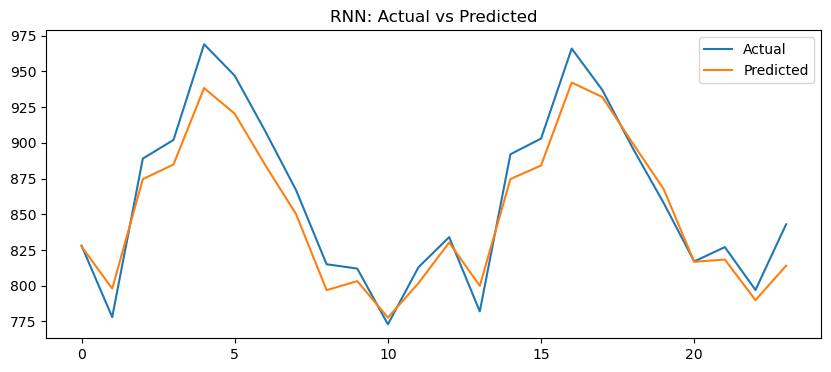

In [42]:
plt.figure(figsize=(10, 4))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_rnn_inv, label='Predicted')
plt.title(f'RNN: Actual vs Predicted')
plt.legend()
plt.show()

### LSTM

In [27]:
lstm_model = build_model('LSTM', window_size)

In [28]:
lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val), 
               epochs=50, batch_size=16, verbose=1, callbacks=[es])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.1067 - val_loss: 0.0831
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0292 - val_loss: 0.0448
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0328 - val_loss: 0.0269
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0245 - val_loss: 0.0390
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0268 - val_loss: 0.0369
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0245 - val_loss: 0.0257
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0248 - val_loss: 0.0255
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0235 - val_loss: 0.0292
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0233 - val_loss: 0.0275
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0227 - val_loss: 0.0255


In [29]:
y_pred_lstm_scaled = lstm_model.predict(X_test)
y_pred_lstm_inv = scaler.inverse_transform(y_pred_lstm_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step


In [43]:
rmse_lstm= np.sqrt(mean_squared_error(y_test_inv, y_pred_lstm_inv))
mae_lstm= mean_absolute_error(y_test_inv, y_pred_lstm_inv)
mape_lstm= np.mean(np.abs((y_test_inv - y_pred_lstm_inv) / y_test_inv)) * 100

In [44]:
print(f"LSTM -> RMSE: {rmse_lstm:.2f}, MAE: {mae_lstm:.2f}, MAPE: {mape_lstm:.2f}%")

LSTM -> RMSE: 125.39, MAE: 108.62, MAPE: 12.20%


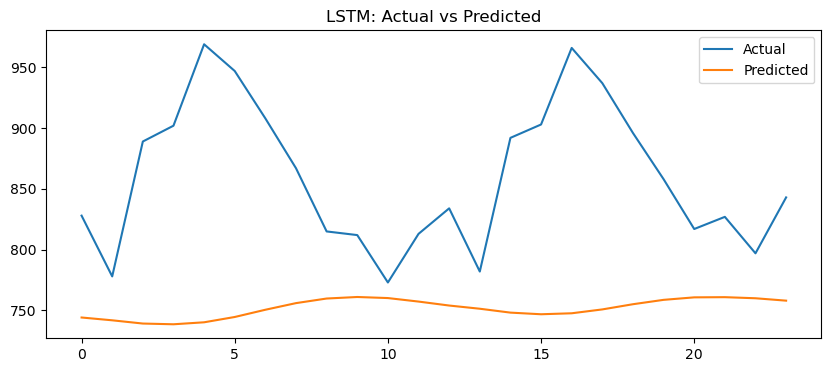

In [45]:
plt.figure(figsize=(10, 4))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_lstm_inv, label='Predicted')
plt.title(f'LSTM: Actual vs Predicted')
plt.legend()
plt.show()

### GRU

In [33]:
gru_model = build_model('GRU', window_size)

In [34]:
gru_model.fit(X_train, y_train, validation_data=(X_val, y_val), 
              epochs=50, batch_size=16, verbose=1, callbacks=[es])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.1582 - val_loss: 0.1909
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0448 - val_loss: 0.0314
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0324 - val_loss: 0.0270
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0311 - val_loss: 0.0295
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0251 - val_loss: 0.0446
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0254 - val_loss: 0.0449
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0240 - val_loss: 0.0341
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0227 - val_loss: 0.0292
Epoch 9/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0224 - val_loss: 0.0278
Epoch 10/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0217 - val_loss: 0.0303


In [35]:
y_pred_gru_scaled = gru_model.predict(X_test)
y_pred_gru_inv = scaler.inverse_transform(y_pred_gru_scaled)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


In [48]:
rmse_gru= np.sqrt(mean_squared_error(y_test_inv, y_pred_gru_inv))
mae_gru= mean_absolute_error(y_test_inv, y_pred_gru_inv)
mape_gru= np.mean(np.abs((y_test_inv - y_pred_gru_inv) / y_test_inv)) * 100

In [49]:
print(f"GRU -> RMSE: {rmse_gru:.2f}, MAE: {mae_gru:.2f}, MAPE: {mape_gru:.2f}%")

GRU -> RMSE: 189.90, MAE: 179.85, MAPE: 20.53%


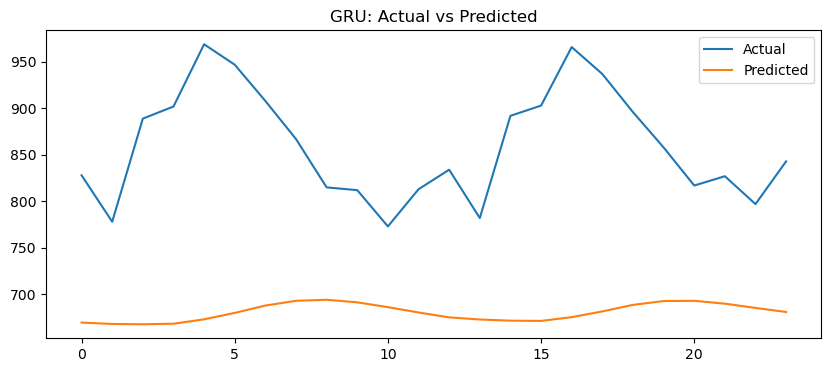

In [50]:
plt.figure(figsize=(10, 4))
plt.plot(y_test_inv, label='Actual')
plt.plot(y_pred_gru_inv, label='Predicted')
plt.title(f'GRU: Actual vs Predicted')
plt.legend()
plt.show()

In [51]:
results = {
    'RNN': {'rmse': rmse_rnn, 'mae': mae_rnn, 'mape': mape_rnn},
    'LSTM': {'rmse': rmse_lstm, 'mae': mae_lstm, 'mape': mape_lstm},
    'GRU': {'rmse': rmse_gru, 'mae': mae_gru, 'mape': mape_gru}
}

In [52]:
# Convert to DataFrame
comp_df = pd.DataFrame({m: {"RMSE": r['rmse'], "MAE": r['mae'], "MAPE": r['mape']} 
                        for m, r in results.items()}).T

In [53]:
print('\nModel Comparison:')
print(comp_df)


Model Comparison:
            RMSE         MAE       MAPE
RNN    16.579717   14.057271   1.610486
LSTM  125.385651  108.618179  12.195082
GRU   189.898345  179.848091  20.525784


In [54]:
# Find best model based on RMSE
best_model_name = min(results, key=lambda x: results[x]['rmse'])
print(f"\nBest model: {best_model_name}")


Best model: RNN


In [62]:
def forecast_future(model, last_window, n_steps, scaler):
    """
    Forecast future n_steps using last_window of size 'window_size'.
    model: trained RNN/LSTM/GRU model
    last_window: last observed data (scaled)
    n_steps: number of future months to predict
    scaler: scaler used to scale/normalize the data
    """
    window = last_window.copy()
    preds = []

    for _ in range(n_steps):
        # reshape to (1, window_size, 1) for RNN/LSTM/GRU
        p_scaled = model.predict(window.reshape(1, window.shape[0], 1))
        p = scaler.inverse_transform(p_scaled)[0, 0]  # inverse scale
        preds.append(p)
        window = np.append(window[1:], p_scaled)  # slide window
    
    return preds


In [71]:
best_model=rnn_model
last_window = df_scaled[-12:]  # last 12 months
future_preds = forecast_future(best_model, last_window, n_steps=12, scaler=scaler)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [72]:
print("Forecasted milk production for next 12 months:")
for i, val in enumerate(future_preds, 1):
    print(f"Month {i}: {val:.2f}")

Forecasted milk production for next 12 months:
Month 1: 839.65
Month 2: 804.81
Month 3: 877.52
Month 4: 883.87
Month 5: 935.44
Month 6: 920.57
Month 7: 892.38
Month 8: 864.80
Month 9: 823.90
Month 10: 833.05
Month 11: 808.41
Month 12: 838.03


In [74]:
#### Visualize the forecast
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=12, freq='MS')

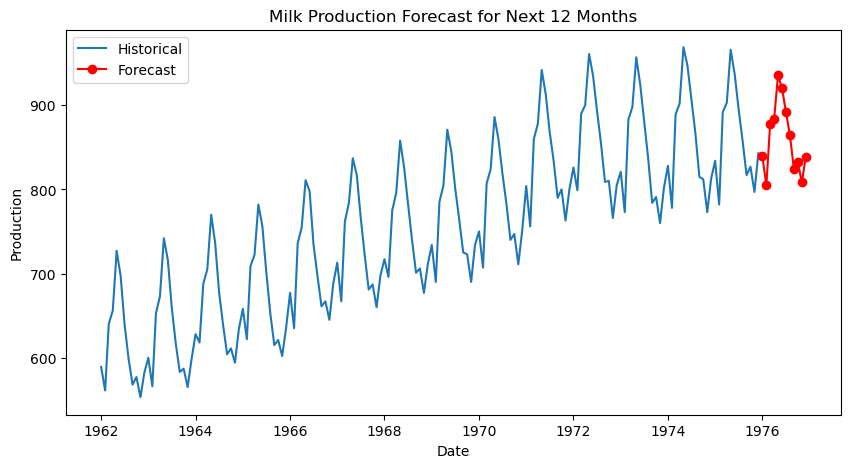

In [75]:
# Plot
plt.figure(figsize=(10,5))
plt.plot(df.index, df['Production'], label='Historical')
plt.plot(future_dates, future_preds, label='Forecast', color='red', marker='o')
plt.title("Milk Production Forecast for Next 12 Months")
plt.xlabel("Date")
plt.ylabel("Production")
plt.legend()
plt.show()